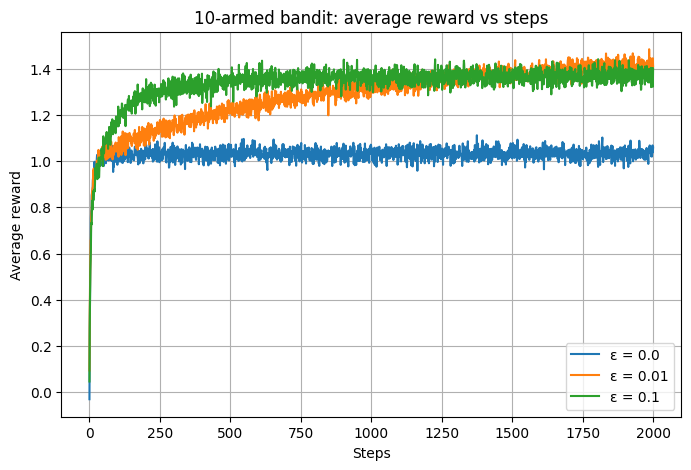

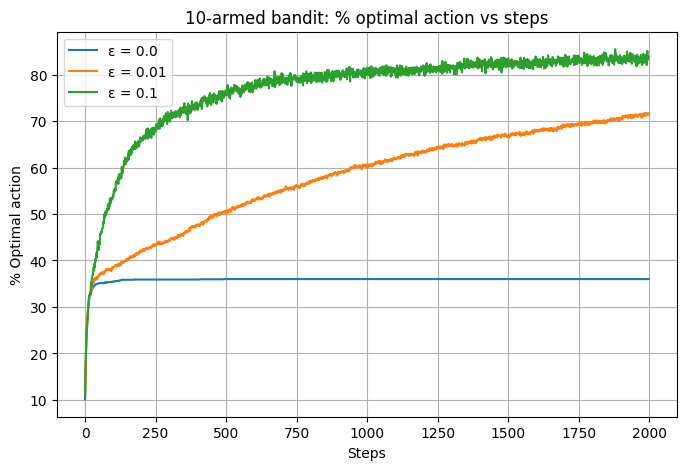

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

def create_bandit(k=10):
    true_values = np.random.normal(loc=0.0, scale=1.0, size=k)
    return true_values


def epsilon_greedy(k=10, epsilon=0.1, steps=2000, runs=2000):
    rewards = np.zeros((runs, steps))
    optimal_actions = np.zeros((runs, steps))
    
    for r in range(runs):
        true_values = create_bandit(k)
        
        optimal_arm = np.argmax(true_values)
    
        Q = np.zeros(k)     
        N = np.zeros(k)      
        
        for t in range(steps):
            
            if np.random.rand() < epsilon:
                action = np.random.randint(0, k)
            else:
                action = np.argmax(Q)
            
            reward = np.random.normal(loc=true_values[action], scale=1.0)
            
            
            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]
            
            
            rewards[r, t] = reward
            if action == optimal_arm:
                optimal_actions[r, t] = 1.0
    
    avg_rewards = rewards.mean(axis=0)
    optimal_action_perc = optimal_actions.mean(axis=0) * 100.0  
    
    return avg_rewards, optimal_action_perc


k = 10
steps = 2000
runs = 2000  

epsilons = [0.0, 0.01, 0.1]

results = {}
for eps in epsilons:
    avg_rewards, optimal_perc = epsilon_greedy(k=k, epsilon=eps, steps=steps, runs=runs)
    results[eps] = (avg_rewards, optimal_perc)


plt.figure(figsize=(8, 5))

for eps in epsilons:
    avg_rewards, _ = results[eps]
    plt.plot(avg_rewards, label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title(f"{k}-armed bandit: average reward vs steps")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))

for eps in epsilons:
    _, optimal_perc = results[eps]
    plt.plot(optimal_perc, label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title(f"{k}-armed bandit: % optimal action vs steps")
plt.legend()
plt.grid(True)
plt.show()